# 01 Understanding Sequential Data and Time Series Prediction

## 📚 Learning Objectives

By completing this notebook, you will:
- **Understand** what sequential data is (order matters: time series, text, speech) and why we need models that use context (RNNs, Transformers)
- **Build** a simple **time series** dataset (past values → next value) and run a **baseline** that flattens the sequence (no RNN yet)
- **See** how we measure performance (e.g. MSE for next-value prediction) and compare with RNNs in `02_rnn_basics.ipynb` and later

## 🌍 Real life

**Where is this used?** Sequential data appears in **time series** (stock prices, sensors), **text** (sentences, documents), and **speech**. Order matters: "dog bites man" vs "man bites dog." In the next notebooks we use RNNs and Transformers for such data; here we set the context with a simple baseline.

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 4, lesson 06 "RNN, LSTM, and GRU for Sequential Data" — you met sequence models there; here we start further back, from why order matters at all.

---

**📌 Covers slide(s):** **21** — Understanding Sequential Data. *Do this notebook after that slide.*

**Next:** `02_rnn_basics.ipynb` introduces RNNs for actual sequences.

---


## Theory (short)

- **Sequential data:** Order matters (e.g. time steps, words in a sentence). Examples: time series (sensors, stock prices), text, speech.
- **Time series prediction:** We use **past values** in the sequence to predict the **next value** (or a label). Here we build sequences of length `seq_len` and predict the next step.
- **Why not a plain MLP?** A feedforward network can take flattened sequences but treats each position independently; it doesn't model "what came before." In **02_rnn_basics** we use **RNNs** that maintain a hidden state over time.
- **This notebook:** We use **synthetic time series data** and a **simple baseline** (flatten the sequence and train a small model) to predict the next value. You will see sequential data creation and evaluation; then in **02_rnn_basics** we use RNNs to exploit order.

## 📥 Inputs & 📤 Outputs

**Inputs:** NumPy, scikit-learn. **Synthetic time series** (no download): we generate a 1D sequence (e.g. sine wave + noise or random walk) and create (sequence, next_value) pairs.

**Dataset:** Sequential — synthetic time series; we use a sliding window to form sequences of length `seq_len` and predict the next value (regression) or a binary label (e.g. up/down). RNN notebooks (02 onward) use real text or longer sequences.

**Outputs:** Mean squared error (or accuracy if we classify up/down), and a short plot of true vs predicted next value for a few steps. You will see how we build and evaluate on sequential data before using RNNs in the next notebooks.

---


Mean squared error (baseline on sequential data): 0.100221
(In 02_rnn_basics we use RNNs to model the sequence order explicitly.)


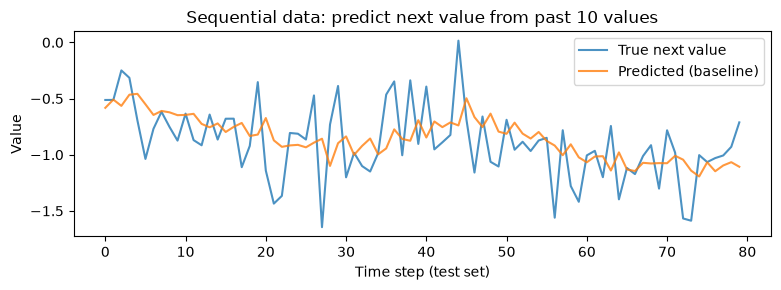

In [1]:
# Sequential data: synthetic time series and baseline prediction (next value from past sequence)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# 1) Generate synthetic time series (e.g. sine + noise) — sequential data
rng = np.random.default_rng(42)
T = 1000
t = np.linspace(0, 4 * np.pi, T)
series = np.sin(t) + 0.3 * rng.normal(size=T)  # sequential: order matters

# 2) Build sequences: use past seq_len values to predict the next value
seq_len = 10
X_list, y_list = [], []
for i in range(len(series) - seq_len):
    X_list.append(series[i : i + seq_len])
    y_list.append(series[i + seq_len])
X = np.array(X_list)
y = np.array(y_list)

# 3) Train/test split (keep temporal order: train on earlier, test on later)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 4) Baseline: flatten sequence and use a simple regressor (ignores order structure; RNNs will use it in 02)
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean squared error (baseline on sequential data): {mse:.6f}")
print("(In 02_rnn_basics we use RNNs to model the sequence order explicitly.)")

# 5) Plot: true vs predicted next value for a short test segment
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(y_test[:80], label="True next value", alpha=0.8)
ax.plot(y_pred[:80], label="Predicted (baseline)", alpha=0.8)
ax.set_xlabel("Time step (test set)")
ax.set_ylabel("Value")
ax.set_title("Sequential data: predict next value from past 10 values")
ax.legend()
plt.tight_layout()
plt.show()


## 🌍 Real-World Worked Example — Stock Trend Prediction (and an Honesty Check)

**Industry context:** Hedge funds and trading platforms really do run LSTMs on price
sequences — and most claimed "prediction accuracy" evaporates once it is compared
against the right baseline.

We train an LSTM to predict whether a **synthetic stock price** goes up or down the
next day. The data is a **random walk with upward drift**: each day's move is drawn
independently of the past, so the *only* learnable signal is the drift itself. That
makes the honest benchmark the **base rate** (always predict the majority direction),
not the 50% coin flip that "stock prediction" demos usually quote. Watch how the
comparison changes the story.

*Preview: this example uses an **LSTM**, which notebooks `02`–`03` introduce properly. Run it as a demo now and revisit the model code after `03_lstm_advanced`.*

LSTM direction accuracy:          59.2%
Always-predict-majority baseline: 59.2%  (test set is 59.2% 'up' days)
LSTM edge over the honest baseline: +0.0 points

By construction, each day's move is INDEPENDENT of the past 20 days,
so no model can consistently beat the base rate on this data — any gap
either way is test-set noise (~+/-3.6 points at n≈196).
Lesson: always compare a 'market predictor' to the base rate, not to 50%.


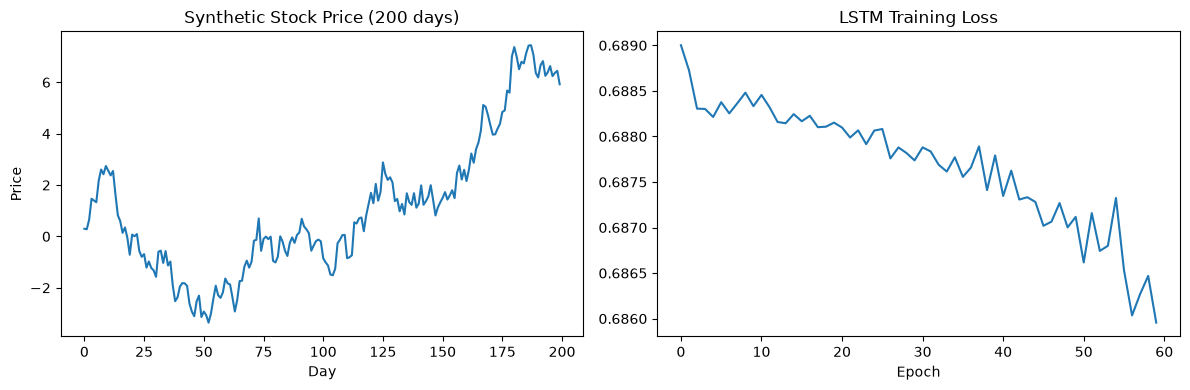

In [2]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt

# ── Generate a stock-like price series: a RANDOM WALK with drift ─────────
# Each daily step is independent N(+0.05, 0.5) — the past 20 days carry NO
# information about tomorrow beyond the constant drift.
np.random.seed(42)
torch.manual_seed(0)
n = 1000
price = np.cumsum(np.random.randn(n) * 0.5 + 0.05).astype(np.float32)

# Create sequences: use 20 days to predict direction on day 21
SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(price) - SEQ_LEN - 1):
    X_list.append(price[i:i+SEQ_LEN])
    y_list.append(1 if price[i+SEQ_LEN] > price[i+SEQ_LEN-1] else 0)

X_arr = np.array(X_list); y_arr = np.array(y_list)
# Normalise each sequence
X_arr = (X_arr - X_arr.mean(1,keepdims=True)) / (X_arr.std(1,keepdims=True)+1e-8)

split = int(0.8*len(X_arr))
Xtr = torch.tensor(X_arr[:split]).unsqueeze(-1)  # (N, 20, 1)
Ytr = torch.tensor(y_arr[:split], dtype=torch.long)
Xte = torch.tensor(X_arr[split:]).unsqueeze(-1)
Yte = torch.tensor(y_arr[split:], dtype=torch.long)

# ── LSTM Model ──────────────────────────────────────────────────────
class TrendLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, batch_first=True, num_layers=2, dropout=0.2)
        self.fc   = nn.Linear(32, 2)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])   # last time step

model   = TrendLSTM()
opt     = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
losses  = []

for epoch in range(60):
    model.train()
    loss = loss_fn(model(Xtr), Ytr)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

# ── Honest evaluation: compare against the base rate, not against 50% ─────
model.eval()
with torch.no_grad():
    acc = (model(Xte).argmax(1)==Yte).float().mean().item()
p_up = Yte.float().mean().item()
base = max(p_up, 1.0 - p_up)   # always predict the majority direction

print(f"LSTM direction accuracy:          {acc*100:.1f}%")
print(f"Always-predict-majority baseline: {base*100:.1f}%  (test set is {p_up*100:.1f}% 'up' days)")
print(f"LSTM edge over the honest baseline: {(acc-base)*100:+.1f} points")
print()
print("By construction, each day's move is INDEPENDENT of the past 20 days,")
print("so no model can consistently beat the base rate on this data — any gap")
print("either way is test-set noise (~+/-3.6 points at n≈196).")
print("Lesson: always compare a 'market predictor' to the base rate, not to 50%.")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(price[:200]); plt.title("Synthetic Stock Price (200 days)"); plt.xlabel("Day"); plt.ylabel("Price")
plt.subplot(1,2,2)
plt.plot(losses); plt.title("LSTM Training Loss"); plt.xlabel("Epoch")
plt.tight_layout(); plt.show()

## Summary

**What you did:** (1) Generated synthetic time series data (sequential). (2) Built sequences (past `seq_len` values → next value). (3) Trained a baseline regressor on flattened sequences and evaluated with MSE. (4) Plotted true vs predicted next value.

**In real life you'd also:** Use real time series (sensors, stock, logs), tune `seq_len` and model; in the next notebook we use RNNs to exploit order. **Next:** `02_rnn_basics.ipynb` introduces RNNs for sequences.

## 📚 References

1. Elman, J. L. (1990). *Finding Structure in Time*. Cognitive Science 14(2), 179-211. https://doi.org/10.1207/s15516709cog1402_1
2. Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation 9(8), 1735-1780. https://doi.org/10.1162/neco.1997.9.8.1735
3. Lim, B. & Zohren, S. (2021). *Time-Series Forecasting With Deep Learning: A Survey*. Philosophical Transactions of the Royal Society A. https://arxiv.org/abs/2004.13408